# Video Classification

This task involves **video binary classification** problem. The goal is to
construct a model capable of distinguishing between different types of human actions. The chosen classes are the following:

*   Archery
*   SkyDiving







## Data Loading

Instead of loading your data on Colab, losing it whenever you disconnect the runtime, you can **load the dataset on Google Drive** (using the same account you are using for Colab), and then execute the cell below to connect the notebook with your Drive, accessing the files directly from the notebook in a much faster way.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
zip_file_path = '/content/drive/MyDrive/actions.zip'
!unzip -q -o "{zip_file_path}"

In [ ]:
# Unzip the data folder if you prefer loading data on Colab every time
# !unzip /content/actions.zip

##Data Preprocessing

In [ ]:
import cv2
import torch
import numpy as np

When dealing with videos, we need to ensure two things:


*   Every video must be of **same frame length**
*   Every frame must have **same resolution**

This is because models expect a fixed-size input.



In [ ]:
# Converts a raw video into a 4d-tensor ready to be processed by Deep Models
def load_video(path, max_frames=20, resize=(224, 224)):

    # Open the stream to point the video
    cap = cv2.VideoCapture(path)
    frames = []

    # Get total frames to calculate the interval
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # get the number of frames for the current video
    interval = max(1, total_frames // max_frames) # compute how many frames we need to jump to have exactly 20 frames

    for i in range(max_frames):
        # Set the reader to a specific frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)

        # Read the frame
        ret, frame = cap.read()   # frame is the frame (NumPy array), while ret is a boolean indicating whether the frame was retrieved successfully
        if not ret:   # safety check
            break

        # Convert BGR (OpenCV default) to RGB
        # OpenCV uses BGR channels, but PyTorch models expect RGB -> we need to convert
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, resize)
        frames.append(frame)

    cap.release()

    # Shape: (frames, height, width, channels) -> (frames, channels, height, width)
    # PyTorch models expect tensors in the form [channels, height, width], while OpenCV uses [height, width, channels]
    video_tensor = torch.tensor(np.array(frames)).permute(0, 3, 1, 2).float()
    return video_tensor / 255.0  # Normalize

In [ ]:
import os
from torch.utils.data import Dataset

In [ ]:
# Define a custom dataset class to easily access data
class VideoDataset(Dataset):

    # The __init__ method is called once the first time the dataset is instantiated
    # It builds a map for our data
    def __init__(self, root_dir, max_frames=20):
        self.samples = []

        # Models need integer to represent classes: we build a dictionary
        self.class_to_idx = # TODO create a dictionary to map Archery to 0 and SkyDiving to 1

        for class_name in self.class_to_idx.keys():   # Iterate over each class of the dictionary
            class_path = os.path.join(root_dir, class_name) # Build the path to the files for the current class

            for video_name in os.listdir(class_path): # Iterate over each video of the current class
                if video_name.endswith('.avi'):   # Ensure it is a .avi video

                    # Save the path to the video and the integer representing its class
                    self.samples.append((os.path.join(class_path, video_name),
                                         self.class_to_idx[class_name]))

    # Returns the number of samples in the current dataset
    def __len__(self):
        return None   # TODO

    # Retrieve the idx-th item (video, label) from samples
    def __getitem__(self, idx):
        path, label = None  # TODO
        video = None  # TODO
        return video, label

In [ ]:
# Creating datasets for each folder (train, val, test)
train_ds = None   # TODO
val_ds   = None   # TODO
test_ds  = None   # TODO

print(f"Videos found: Train({len(train_ds)}), Val({len(val_ds)}), Test({len(test_ds)})")

In [ ]:
# Create the DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = None   # TODO
val_loader   = None   # TODO
test_loader  = None   # TODO

##Model Definition


Videos are **sequences of images.**
This means that to process videos we need to merge the capability of **handling grid-like structured data** (images) and **sequential data.**

We already saw two classes of models suitable for each case: Convolutional Neural Networks **(CNNs)** for images, and **LSTMs** for sequences.

To process videos, we **merge these models.**
We will use a **CNN** to **extract features** for each frame, and then we will pass these features **through a LSTM** block, **to capture time dependency** between frames.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
class FrameEncoder(nn.Module):
    def __init__(self, embed_size=512):
        super(FrameEncoder, self).__init__()
        # Layer 1: 224x224 -> 112x112
        self.conv1 = None   # TODO
        self.bn1 = nn.BatchNorm2d(16)

        # Layer 2: 112x112 -> 56x56
        self.conv2 = None   # TODO
        self.bn2 = nn.BatchNorm2d(32)

        # Layer 3: 56x56 -> 28x28
        self.conv3 = None   # TODO
        self.bn3 = nn.BatchNorm2d(64)

        # Global Average Pooling: Shrinks any HxW to 1x1
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final projection to match the LSTM input
        self.fc = None  # TODO Note that the output size should match the embed_size of the LSTM block
        self.relu = nn.ReLU()

    def forward(self, x):
        x = None  # TODO first conv layer
        x = None  # TODO second conv layer
        x = None  # TODO third conv layer

        x = self.adaptive_pool(x) # Shape: [batch, 64, 1, 1]
        x = x.view(x.size(0), -1) # Flatten: [batch, 64]

        x = None  # TODO final fully connected layer
        return x

In [ ]:
class CustomVideoModel(nn.Module):
    def __init__(self, num_classes=2, hidden_size=256):
        super(CustomVideoModel, self).__init__()

        self.encoder = None   # TODO instantiate the CNN using 512 as embed_size
        self.lstm = None      # TODO instantiate a LSTM block
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [batch, frames, channels, h, w]
        b, f, c, h, w = x.shape

        # Process every frame through our Custom CNN
        # Reshape to [b*f, c, h, w] to treat frames as individual images
        x = x.view(b * f, c, h, w)

        # Output: [b*f, 512]
        features = # TODO apply the CNN to extract the features

        # Reshape back for the LSTM
        features = features.view(b, f, -1) # Output: [b, f, 512]

        # Temporal processing (LSTM)
        _, (hn, _) = None   # TODO apply LSTM to features

        # Final classification using the last hidden state
        logits = self.fc(hn[-1])
        return logits

##Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
model = None  # TODO

# Loss Function (Standard for multi-class)
criterion = None  # TODO

# Optimizer (Adam is usually best for CNN-LSTM combos)
optimizer = None  # TODO

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    pass  # TODO define your training and validation loop

##Validation over the Test Set

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

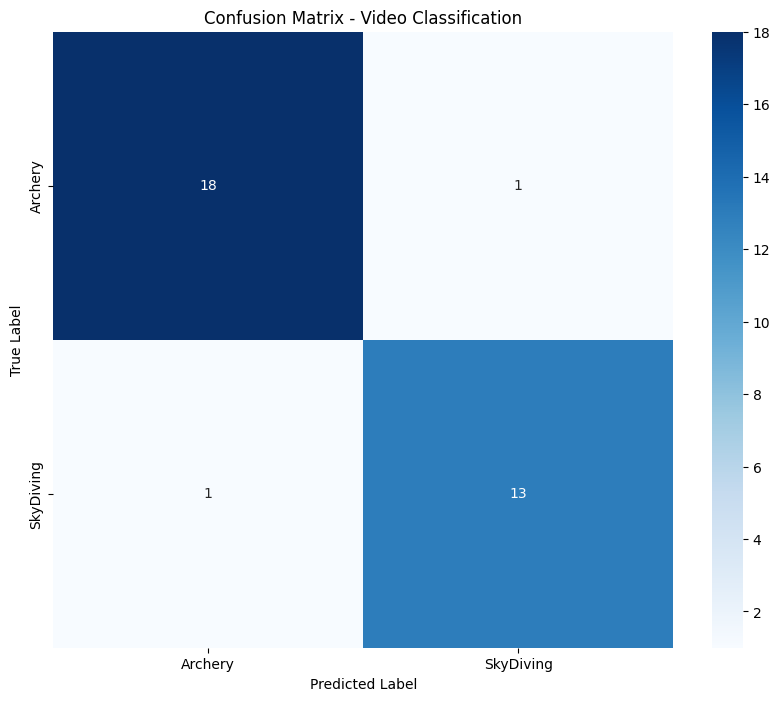


Classification Report:
              precision    recall  f1-score   support

     Archery       0.95      0.95      0.95        19
   SkyDiving       0.93      0.93      0.93        14

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



In [ ]:
def evaluate_and_plot_cm(model, test_loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for videos, labels in test_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Video Classification')
    plt.show()

    # Detailed Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

# Run the evaluation
class_names = ["Archery", "SkyDiving"]
evaluate_and_plot_cm(model, test_loader, device, class_names)